##  Environment Setup
Initialize Apache Spark session connected to HDFS.

In [ ]:
from pyspark.sql import SparkSession

# Initialize Spark connected to HDFS
spark = SparkSession.builder \
    .appName("Exoplanet Analytics") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

# Load the 3 main datasets directly from HDFS
HDFS = "hdfs://namenode:9000/exoplanet/raw/"

pscomp     = spark.read.csv(HDFS + "PSCompPars_2026.05.15_15.27.50.csv",
                             header=True, inferSchema=True)
cumulative = spark.read.csv(HDFS + "cumulative_2026.05.15_15.28.25.csv",
                             header=True, inferSchema=True)
kepler_star = spark.read.csv(HDFS + "kepler_stellar.csv",
                              header=True, inferSchema=True)

# Verify
print(f"PSCompPars:     {pscomp.count():,} rows x {len(pscomp.columns)} cols")
print(f"Cumulative KOI: {cumulative.count():,} rows x {len(cumulative.columns)} cols")
print(f"Kepler Stellar: {kepler_star.count():,} rows x {len(kepler_star.columns)} cols")

## 1. Load Main Datasets from HDFS
Load the 3 primary datasets (PSCompPars, Cumulative KOI, Kepler Stellar)
directly from HDFS using PySpark with NASA comment filter.

In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Exoplanet Analytics") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

HDFS = "hdfs://namenode:9000/exoplanet/raw/"

# Read with comment filter
pscomp = spark.read.csv(
    HDFS + "PSCompPars_2026.05.15_15.27.50.csv",
    header=True, inferSchema=True, comment="#"
)

cumulative = spark.read.csv(
    HDFS + "cumulative_2026.05.15_15.28.25.csv",
    header=True, inferSchema=True, comment="#"
)

kepler_star = spark.read.csv(
    HDFS + "kepler_stellar.csv",
    header=True, inferSchema=True, comment="#"
)

print(f"PSCompPars:     {pscomp.count():,} rows x {len(pscomp.columns)} cols")
print(f"Cumulative KOI: {cumulative.count():,} rows x {len(cumulative.columns)} cols")
print(f" Kepler Stellar: {kepler_star.count():,} rows x {len(kepler_star.columns)} cols")

PSCompPars:     6,287 rows x 84 cols
Cumulative KOI: 9,564 rows x 49 cols
 Kepler Stellar: 200,038 rows x 99 cols


## 2. Exploratory Data Analysis — Missing Values
Analyze missing value percentages across all columns
to guide preprocessing decisions.

In [8]:
from pyspark.sql.functions import col, count, when, isnan
from pyspark.sql.types import NumericType

def missing_report(df, name):
    total = df.count()
    print(f"\n{'='*45}")
    print(f"  {name} | {total:,} rows | {len(df.columns)} cols")
    print(f"{'='*45}")
    
    # Check numeric vs non-numeric separately
    numeric_cols = [f.name for f in df.schema.fields 
                    if isinstance(f.dataType, NumericType)]
    other_cols   = [f.name for f in df.schema.fields 
                    if not isinstance(f.dataType, NumericType)]
    
    exprs = []
    for c in numeric_cols:
        exprs.append(
            (count(when(col(c).isNull() | isnan(c), c)) / total * 100).alias(c)
        )
    for c in other_cols:
        exprs.append(
            (count(when(col(c).isNull(), c)) / total * 100).alias(c)
        )
    
    miss_pd = df.select(exprs).toPandas().T
    miss_pd.columns = ['missing_%']
    miss_pd = miss_pd[miss_pd['missing_%'] > 0] \
                .sort_values('missing_%', ascending=False)
    
    print(f"  Columns with missing: {len(miss_pd)} / {len(df.columns)}")
    print(miss_pd.head(10).to_string())

missing_report(pscomp,      "PSCompPars")
missing_report(cumulative,  "Cumulative KOI")
missing_report(kepler_star, "Kepler Stellar")


  PSCompPars | 6,287 rows | 84 cols
  Columns with missing: 71 / 84
                 missing_%
pl_eqterr2       70.924129
pl_eqterr1       70.924129
pl_orbeccenerr2  70.097026
pl_orbeccenerr1  70.097026
st_spectype      63.130269
pl_bmassjerr2    52.043900
pl_bmassjerr1    52.043900
pl_bmasseerr2    52.043900
pl_bmasseerr1    52.043900
pl_insolerr1     42.055034

  Cumulative KOI | 9,564 rows | 49 cols
  Columns with missing: 36 / 49
                 missing_%
koi_teq_err1    100.000000
koi_teq_err2    100.000000
kepler_name      71.277708
koi_score        15.788373
koi_steff_err2    5.050188
koi_srad_err2     4.893350
koi_slogg_err2    4.893350
koi_slogg_err1    4.893350
koi_steff_err1    4.893350
koi_srad_err1     4.893350

  Kepler Stellar | 200,038 rows | 99 cols
  Columns with missing: 84 / 99
              missing_%
datalink_dvr  91.387136
kmag_err       1.913636
teff_err2      1.724172
mass_err1      1.594697
mass_err2      1.593197
radius_err1    1.592697
dens_err2      1.5926

## 3. Data Preprocessing — Step 1: Drop Error Columns
Remove measurement uncertainty columns (err1, err2)
and columns with >80% missing values.

In [9]:
from pyspark.sql.functions import col, when, isnan
from pyspark.sql.types import NumericType

# ── Step 1: Drop error columns ──
def drop_error_cols(df, name):
    err_cols = [c for c in df.columns 
                if c.endswith(('err1','err2','lim','str'))]
    df_clean = df.drop(*err_cols)
    print(f"{name}: {len(df.columns)} cols → {len(df_clean.columns)} cols "
          f"(dropped {len(err_cols)} error columns)")
    return df_clean

pscomp_c  = drop_error_cols(pscomp,      "PSCompPars")
cumul_c   = drop_error_cols(cumulative,  "Cumulative")
kstar_c   = drop_error_cols(kepler_star, "Kepler Stellar")

# ── Step 2: Drop columns with >80% missing ──
def drop_high_missing(df, name, threshold=80):
    total = df.count()
    numeric_cols = [f.name for f in df.schema.fields 
                    if isinstance(f.dataType, NumericType)]
    other_cols   = [f.name for f in df.schema.fields 
                    if not isinstance(f.dataType, NumericType)]
    
    exprs = []
    for c in numeric_cols:
        exprs.append(
            (count(when(col(c).isNull() | isnan(c), c)) / total * 100).alias(c)
        )
    for c in other_cols:
        exprs.append(
            (count(when(col(c).isNull(), c)) / total * 100).alias(c)
        )
    
    miss = df.select(exprs).toPandas().T
    miss.columns = ['pct']
    to_drop = miss[miss['pct'] > threshold].index.tolist()
    df_clean = df.drop(*to_drop)
    print(f"{name}: dropped {len(to_drop)} cols above {threshold}% missing "
          f"→ {len(df_clean.columns)} cols remaining")
    return df_clean

pscomp_c = drop_high_missing(pscomp_c,  "PSCompPars")
cumul_c  = drop_high_missing(cumul_c,   "Cumulative")
kstar_c  = drop_high_missing(kstar_c,   "Kepler Stellar")

print("\n Final shapes:")
print(f"   PSCompPars:     {pscomp_c.count()} rows x {len(pscomp_c.columns)} cols")
print(f"   Cumulative:     {cumul_c.count()} rows x {len(cumul_c.columns)} cols")
print(f"   Kepler Stellar: {kstar_c.count()} rows x {len(kstar_c.columns)} cols")

PSCompPars: 84 cols → 32 cols (dropped 52 error columns)
Cumulative: 49 cols → 27 cols (dropped 22 error columns)
Kepler Stellar: 99 cols → 82 cols (dropped 17 error columns)
PSCompPars: dropped 0 cols above 80% missing → 32 cols remaining
Cumulative: dropped 0 cols above 80% missing → 27 cols remaining
Kepler Stellar: dropped 1 cols above 80% missing → 81 cols remaining

 Final shapes:
   PSCompPars:     6287 rows x 32 cols
   Cumulative:     9564 rows x 27 cols
   Kepler Stellar: 200038 rows x 81 cols


## 4. Data Preprocessing — Step 2: Missing Value Imputation
- **Median** for planet columns (skewed distributions)
- **Mean** for stellar columns (normal distributions)
- **Mode** for categorical columns

In [10]:
from pyspark.sql.functions import col, isnan, when, percentile_approx, avg
from pyspark.sql.types import NumericType, StringType

# ── Helper: get median for a column ──
def get_median(df, col_name):
    return df.select(
        percentile_approx(col_name, 0.5)
    ).collect()[0][0]

def get_mean(df, col_name):
    return df.select(avg(col_name)).collect()[0][0]

def get_mode(df, col_name):
    return df.groupBy(col_name).count() \
             .orderBy('count', ascending=False) \
             .first()[0]

# ── PSCompPars ──
# Median for planet columns
planet_median = ['pl_bmasse', 'pl_rade', 'pl_eqt',
                 'pl_orbper', 'pl_orbsmax', 'pl_insol']
for c in planet_median:
    if c in pscomp_c.columns:
        med = get_median(pscomp_c, c)
        pscomp_c = pscomp_c.fillna({c: med})

# Mean for stellar columns
stellar_mean = ['st_teff', 'st_rad', 'st_mass', 'st_lum', 'st_logg', 'st_met']
for c in stellar_mean:
    if c in pscomp_c.columns:
        mn = get_mean(pscomp_c, c)
        pscomp_c = pscomp_c.fillna({c: mn})

# Mode for categorical
for c in ['discoverymethod', 'disc_facility']:
    if c in pscomp_c.columns:
        mod = get_mode(pscomp_c, c)
        pscomp_c = pscomp_c.fillna({c: mod})

# disc_year
if 'disc_year' in pscomp_c.columns:
    mod = get_mode(pscomp_c, 'disc_year')
    pscomp_c = pscomp_c.fillna({'disc_year': mod})

# ── Cumulative KOI ──
koi_median = ['koi_period', 'koi_depth', 'koi_prad',
              'koi_teq', 'koi_srad', 'koi_impact', 'koi_insol', 'koi_kepmag']
for c in koi_median:
    if c in cumul_c.columns:
        med = get_median(cumul_c, c)
        cumul_c = cumul_c.fillna({c: med})

koi_mean = ['koi_steff', 'koi_slogg', 'koi_smet']
for c in koi_mean:
    if c in cumul_c.columns:
        mn = get_mean(cumul_c, c)
        cumul_c = cumul_c.fillna({c: mn})

if 'koi_score' in cumul_c.columns:
    cumul_c = cumul_c.fillna({'koi_score': 0.0})

# ── Kepler Stellar ──
kstar_median = ['dens', 'feh', 'logg']
for c in kstar_median:
    if c in kstar_c.columns:
        med = get_median(kstar_c, c)
        kstar_c = kstar_c.fillna({c: med})

kstar_mean = ['teff', 'mass', 'radius']
for c in kstar_mean:
    if c in kstar_c.columns:
        mn = get_mean(kstar_c, c)
        kstar_c = kstar_c.fillna({c: mn})

# ── Verify ──
print("Missing values after Imputation:")
print(f"  PSCompPars:     {pscomp_c.where(col('pl_bmasse').isNull()).count()} missing in pl_bmasse")
print(f"  Cumulative:     {cumul_c.where(col('koi_period').isNull()).count()} missing in koi_period")
print(f"  Kepler Stellar: {kstar_c.where(col('teff').isNull()).count()} missing in teff")

Missing values after Imputation:
  PSCompPars:     0 missing in pl_bmasse
  Cumulative:     0 missing in koi_period
  Kepler Stellar: 0 missing in teff


## 5. Data Preprocessing — Step 3: Outlier Detection
Detect outliers using the IQR method (Q1 - 3×IQR, Q3 + 3×IQR).

In [11]:
from pyspark.sql.functions import col, percentile_approx

# ── Outlier Detection using IQR ──
def detect_outliers_spark(df, cols, name):
    print(f"\n{'='*45}")
    print(f"  {name} — Outlier Report")
    print(f"{'='*45}")
    
    for c in cols:
        if c not in df.columns:
            continue
        
        q1, q3 = df.select(
            percentile_approx(c, 0.25),
            percentile_approx(c, 0.75)
        ).collect()[0]
        
        if q1 is None or q3 is None:
            continue
            
        iqr   = q3 - q1
        lower = q1 - 3 * iqr
        upper = q3 + 3 * iqr
        
        n_out = df.where(
            (col(c) < lower) | (col(c) > upper)
        ).count()
        
        pct = round(n_out / df.count() * 100, 2)
        if n_out > 0:
            print(f"  {c:<20} outliers: {n_out:>5} ({pct}%)  "
                  f"range: [{round(lower,2)}, {round(upper,2)}]")

# PSCompPars
detect_outliers_spark(pscomp_c,
    ['pl_bmasse', 'pl_rade', 'pl_eqt', 'pl_orbper',
     'pl_orbsmax', 'pl_insol', 'st_teff', 'st_rad', 'st_mass'],
    "PSCompPars")

# Cumulative KOI
detect_outliers_spark(cumul_c,
    ['koi_period', 'koi_depth', 'koi_prad', 'koi_teq',
     'koi_model_snr', 'koi_steff', 'koi_srad', 'koi_insol'],
    "Cumulative KOI")

# Kepler Stellar
detect_outliers_spark(kstar_c,
    ['teff', 'mass', 'radius', 'dens', 'feh', 'logg'],
    "Kepler Stellar")


  PSCompPars — Outlier Report
  pl_bmasse            outliers:   810 (12.88%)  range: [-526.29, 711.75]
  pl_rade              outliers:     2 (0.03%)  range: [-28.04, 41.71]
  pl_eqt               outliers:    85 (1.35%)  range: [-428.0, 2106.0]
  pl_orbper            outliers:   921 (14.65%)  range: [-84.06, 122.61]
  pl_orbsmax           outliers:   973 (15.48%)  range: [-0.58, 0.9]
  pl_insol             outliers:   716 (11.39%)  range: [-425.06, 675.71]
  st_teff              outliers:    33 (0.52%)  range: [2079.0, 8729.0]
  st_rad               outliers:   248 (3.94%)  range: [-0.82, 2.91]
  st_mass              outliers:    64 (1.02%)  range: [-0.17, 2.02]

  Cumulative KOI — Outlier Report
  koi_period           outliers:  1250 (13.07%)  range: [-111.18, 154.61]
  koi_depth            outliers:  1677 (17.53%)  range: [-3350.8, 4856.7]
  koi_prad             outliers:  1069 (11.18%)  range: [-33.52, 48.03]
  koi_teq              outliers:   122 (1.28%)  range: [-1844.0, 3749.0

## 6. Data Preprocessing — Step 4: Outlier Treatment
Cap outliers using Winsorization and remove invalid stellar temperatures.

In [12]:
from pyspark.sql.functions import col, percentile_approx

# ── Outlier Treatment: Capping (Winsorization) ──
def cap_outliers_spark(df, cols, factor=3):
    for c in cols:
        if c not in df.columns:
            continue
        
        q1, q3 = df.select(
            percentile_approx(c, 0.25),
            percentile_approx(c, 0.75)
        ).collect()[0]
        
        if q1 is None or q3 is None:
            continue
        
        iqr   = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        
        df = df.withColumn(c,
            when(col(c) < lower, lower)
            .when(col(c) > upper, upper)
            .otherwise(col(c))
        )
        print(f"  Capped '{c}' → [{round(lower,2)}, {round(upper,2)}]")
    return df

# ── PSCompPars ──
print("PSCompPars — Capping:")
pscomp_c = cap_outliers_spark(pscomp_c,
    ['pl_bmasse', 'pl_rade', 'pl_eqt', 'pl_orbper',
     'pl_orbsmax', 'pl_insol', 'st_rad', 'st_mass'])

# Remove invalid stellar temperatures
before = pscomp_c.count()
pscomp_c = pscomp_c.where(col('st_teff').between(3000, 10000))
print(f"  Removed {before - pscomp_c.count()} rows with invalid st_teff")

# ── Cumulative KOI ──
print("\nCumulative KOI — Capping:")
cumul_c = cap_outliers_spark(cumul_c,
    ['koi_period', 'koi_depth', 'koi_prad', 'koi_teq',
     'koi_model_snr', 'koi_srad', 'koi_insol'])

before = cumul_c.count()
cumul_c = cumul_c.where(col('koi_steff').between(3000, 10000))
print(f"  Removed {before - cumul_c.count()} rows with invalid koi_steff")

# ── Kepler Stellar ──
print("\nKepler Stellar — Capping:")
kstar_c = cap_outliers_spark(kstar_c,
    ['radius', 'mass', 'dens', 'feh', 'logg'])

before = kstar_c.count()
kstar_c = kstar_c.where(col('teff').between(3000, 10000))
print(f"  Removed {before - kstar_c.count()} rows with invalid teff")

# ── Final shapes ──
print("\nFinal shapes after outlier treatment:")
print(f"  PSCompPars:     {pscomp_c.count()} rows x {len(pscomp_c.columns)} cols")
print(f"  Cumulative:     {cumul_c.count()} rows x {len(cumul_c.columns)} cols")
print(f"  Kepler Stellar: {kstar_c.count()} rows x {len(kstar_c.columns)} cols")

PSCompPars — Capping:
  Capped 'pl_bmasse' → [-526.29, 711.75]
  Capped 'pl_rade' → [-28.04, 41.71]
  Capped 'pl_eqt' → [-428.0, 2106.0]
  Capped 'pl_orbper' → [-84.06, 122.61]
  Capped 'pl_orbsmax' → [-0.58, 0.9]
  Capped 'pl_insol' → [-425.06, 675.71]
  Capped 'st_rad' → [-0.82, 2.91]
  Capped 'st_mass' → [-0.17, 2.02]
  Removed 56 rows with invalid st_teff

Cumulative KOI — Capping:
  Capped 'koi_period' → [-111.18, 154.61]
  Capped 'koi_depth' → [-3350.8, 4856.7]
  Capped 'koi_prad' → [-33.52, 48.03]
  Capped 'koi_teq' → [-1844.0, 3749.0]
  Capped 'koi_model_snr' → [-186.0, 276.0]
  Capped 'koi_srad' → [-0.6, 2.75]
  Capped 'koi_insol' → [-2330.14, 3158.42]
  Removed 21 rows with invalid koi_steff

Kepler Stellar — Capping:
  Capped 'radius' → [-1.29, 3.67]
  Capped 'mass' → [-0.02, 2.03]
  Capped 'dens' → [-4.61, 7.16]
  Capped 'feh' → [-1.2, 0.9]
  Capped 'logg' → [2.87, 5.79]
  Removed 515 rows with invalid teff

Final shapes after outlier treatment:
  PSCompPars:     6231 rows 

## 7. Feature Engineering
Create new meaningful features:
- `planet_type` — Rocky / Super-Earth / Neptune-like / Gas Giant
- `stellar_class` — O, B, A, F, G, K, M
- `habitable_zone` — Binary flag
- `disc_decade` — Discovery decade
- `luminosity_proxy` — Stefan-Boltzmann estimate

In [13]:
from pyspark.sql.functions import col, when, udf, floor
from pyspark.sql.types import StringType, IntegerType

# ── Planet Type ──
pscomp_c = pscomp_c.withColumn('planet_type',
    when(col('pl_rade') <= 1.25, 'Rocky')
    .when(col('pl_rade') <= 2.0,  'Super-Earth')
    .when(col('pl_rade') <= 4.0,  'Neptune-like')
    .otherwise('Gas Giant')
)

# ── Stellar Class ──
def stellar_class(teff):
    if teff is None: return 'Unknown'
    if teff >= 7500:  return 'A'
    if teff >= 6000:  return 'F'
    if teff >= 5200:  return 'G'
    if teff >= 3700:  return 'K'
    return 'M'

stellar_class_udf = udf(stellar_class, StringType())

pscomp_c = pscomp_c.withColumn('stellar_class',
    stellar_class_udf(col('st_teff')))

cumul_c  = cumul_c.withColumn('stellar_class',
    stellar_class_udf(col('koi_steff')))

kstar_c  = kstar_c.withColumn('stellar_class',
    stellar_class_udf(col('teff')))

# ── Habitable Zone ──
pscomp_c = pscomp_c.withColumn('habitable_zone',
    when(
        col('pl_eqt').between(273, 373) &
        col('pl_rade').between(0.5, 2.0),
        1
    ).otherwise(0)
)

# ── Discovery Decade ──
pscomp_c = pscomp_c.withColumn('disc_decade',
    (floor(col('disc_year') / 10) * 10).cast(IntegerType())
)

# ── Mass-Radius Ratio ──
pscomp_c = pscomp_c.withColumn('mass_radius_ratio',
    when(col('pl_rade') != 0,
         col('pl_bmasse') / col('pl_rade')
    ).otherwise(None)
)

# ── is_planet for Cumulative ──
cumul_c = cumul_c.withColumn('is_planet',
    when(col('koi_disposition') == 'CONFIRMED', 1).otherwise(0)
)

# ── Transit Ratio ──
cumul_c = cumul_c.withColumn('transit_ratio',
    when(col('koi_period') != 0,
         col('koi_depth') / col('koi_period')
    ).otherwise(0)
)

# ── Luminosity Proxy for Kepler Stellar ──
kstar_c = kstar_c.withColumn('luminosity_proxy',
    (col('radius') ** 2) * ((col('teff') / 5778) ** 4)
)

# ── Summary ──
print("Feature Engineering complete!")
print(f"\nPlanet type distribution:")
pscomp_c.groupBy('planet_type').count() \
        .orderBy('count', ascending=False).show()

print(f"Habitable zone candidates:")
pscomp_c.groupBy('habitable_zone').count().show()

print(f"\nKOI disposition:")
cumul_c.groupBy('koi_disposition').count().show()

Feature Engineering complete!

Planet type distribution:
+------------+-----+
| planet_type|count|
+------------+-----+
|   Gas Giant| 2361|
|Neptune-like| 2098|
| Super-Earth| 1200|
|       Rocky|  572|
+------------+-----+

Habitable zone candidates:
+--------------+-----+
|habitable_zone|count|
+--------------+-----+
|             1|   63|
|             0| 6168|
+--------------+-----+


KOI disposition:
+---------------+-----+
|koi_disposition|count|
+---------------+-----+
|      CONFIRMED| 2745|
|      CANDIDATE| 1977|
| FALSE POSITIVE| 4821|
+---------------+-----+



## 8. Normalization & Encoding
Apply StandardScaler (mean=0, std=1) and StringIndexer
using Spark MLlib Pipeline.

In [14]:
from pyspark.ml.feature import StandardScaler, StringIndexer, VectorAssembler
from pyspark.ml import Pipeline

# ══ PSCompPars ══

# 1. StringIndexer for categorical columns
indexers_pscomp = [
    StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep")
    for c in ['discoverymethod', 'planet_type', 'stellar_class']
]

# 2. Assemble numeric features into vector
num_cols_pscomp = ['pl_bmasse', 'pl_rade', 'pl_eqt', 'pl_orbper',
                   'pl_orbsmax', 'pl_insol', 'st_teff', 'st_rad',
                   'st_mass', 'mass_radius_ratio', 'habitable_zone']

assembler_pscomp = VectorAssembler(
    inputCols=num_cols_pscomp,
    outputCol="features_raw",
    handleInvalid="keep"
)

# 3. StandardScaler
scaler_pscomp = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True, withStd=True
)

# Build pipeline
pipeline_pscomp = Pipeline(stages=indexers_pscomp + [assembler_pscomp, scaler_pscomp])
pscomp_model = pipeline_pscomp.fit(pscomp_c)
pscomp_scaled = pscomp_model.transform(pscomp_c)

# ══ Cumulative KOI ══
indexers_cumul = [
    StringIndexer(inputCol='koi_disposition', outputCol='disposition_idx', handleInvalid="keep"),
    StringIndexer(inputCol='stellar_class',   outputCol='stellar_class_idx', handleInvalid="keep")
]

num_cols_cumul = ['koi_period', 'koi_depth', 'koi_prad', 'koi_teq',
                  'koi_model_snr', 'koi_steff', 'koi_srad',
                  'koi_insol', 'koi_score', 'transit_ratio']

assembler_cumul = VectorAssembler(
    inputCols=num_cols_cumul,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler_cumul = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True, withStd=True
)

pipeline_cumul = Pipeline(stages=indexers_cumul + [assembler_cumul, scaler_cumul])
cumul_model = pipeline_cumul.fit(cumul_c)
cumul_scaled = cumul_model.transform(cumul_c)

# ══ Kepler Stellar ══
indexers_kstar = [
    StringIndexer(inputCol='stellar_class', outputCol='stellar_class_idx', handleInvalid="keep")
]

num_cols_kstar = ['teff', 'mass', 'radius', 'dens', 'feh', 'logg', 'luminosity_proxy']

assembler_kstar = VectorAssembler(
    inputCols=num_cols_kstar,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler_kstar = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True, withStd=True
)

pipeline_kstar = Pipeline(stages=indexers_kstar + [assembler_kstar, scaler_kstar])
kstar_model = pipeline_kstar.fit(kstar_c)
kstar_scaled = kstar_model.transform(kstar_c)

# ── Verify ──
print("Normalization complete!")
print(f"\npscomp_scaled:  {pscomp_scaled.count()} rows")
print(f"cumul_scaled:   {cumul_scaled.count()} rows")
print(f"kstar_scaled:   {kstar_scaled.count()} rows")
print(f"\nSample features vector:")
pscomp_scaled.select('features_scaled').show(3, truncate=True)

Normalization complete!

pscomp_scaled:  6231 rows
cumul_scaled:   9543 rows
kstar_scaled:   199523 rows

Sample features vector:
+--------------------+
|     features_scaled|
+--------------------+
|[2.25099399686028...|
|[2.25099399686028...|
|[2.25099399686028...|
+--------------------+
only showing top 3 rows



## 9. Load & Clean Remaining Datasets — Planet Group
Load TOI, Planetary Systems, K2 Planets from HDFS and clean.

In [15]:
# ══════════════════════════════════════
# Load & Clean Planet Group
# ══════════════════════════════════════

HDFS = "hdfs://namenode:9000/exoplanet/raw/"

# Load
toi           = spark.read.csv(HDFS + "TOI_2026.05.15_15.28.53.csv",
                                header=True, inferSchema=True, comment="#")
planetary_sys = spark.read.csv(HDFS + "planetary_systems.csv",
                                header=True, inferSchema=True, comment="#")
k2_planets    = spark.read.csv(HDFS + "k2_planets.csv",
                                header=True, inferSchema=True, comment="#")

print("Loaded:")
print(f"  TOI:              {toi.count():,} rows x {len(toi.columns)} cols")
print(f"  Planetary Systems:{planetary_sys.count():,} rows x {len(planetary_sys.columns)} cols")
print(f"  K2 Planets:       {k2_planets.count():,} rows x {len(k2_planets.columns)} cols")

# Clean — drop error columns
def drop_err_cols(df, name):
    err = [c for c in df.columns if c.endswith(('err1','err2','lim','str'))]
    df2 = df.drop(*err)
    print(f"  {name}: {len(df.columns)} → {len(df2.columns)} cols")
    return df2

print("\nDropping error columns:")
toi_c           = drop_err_cols(toi,           "TOI")
planetary_sys_c = drop_err_cols(planetary_sys, "Planetary Systems")
k2_c            = drop_err_cols(k2_planets,    "K2 Planets")

Loaded:
  TOI:              7,931 rows x 65 cols
  Planetary Systems:39,860 rows x 355 cols
  K2 Planets:       4,047 rows x 362 cols

Dropping error columns:
  TOI: 65 → 21 cols
  Planetary Systems: 355 → 124 cols
  K2 Planets: 362 → 131 cols


## 10. Clean Planet Group — Imputation & Outlier Treatment
Fill missing values using median/mean strategies,
then remove invalid stellar temperatures.

In [16]:
from pyspark.sql.functions import col, percentile_approx, when, avg

# ══════════════════════════════════════
# Clean Planet Group — Imputation
# ══════════════════════════════════════

def get_median(df, c):
    result = df.select(percentile_approx(c, 0.5)).collect()[0][0]
    return result

def get_mean(df, c):
    result = df.select(avg(c)).collect()[0][0]
    return result

# ── TOI ──
print("TOI imputation:")
for c in ['pl_orbper', 'pl_rade', 'pl_eqt']:
    if c in toi_c.columns:
        med = get_median(toi_c, c)
        if med:
            toi_c = toi_c.fillna({c: med})
            print(f"  {c} filled with median={round(med,2)}")

for c in ['st_teff', 'st_rad']:
    if c in toi_c.columns:
        mn = get_mean(toi_c, c)
        if mn:
            toi_c = toi_c.fillna({c: mn})
            print(f"  {c} filled with mean={round(mn,2)}")

# Remove invalid temperatures
before = toi_c.count()
toi_c = toi_c.where(
    col('st_teff').isNull() | col('st_teff').between(3000, 10000)
)
print(f"  Removed {before - toi_c.count()} rows with invalid st_teff")

# ── Planetary Systems ──
print("\nPlanetary Systems imputation:")
for c in ['pl_bmasse', 'pl_rade', 'pl_eqt', 'pl_orbper', 'pl_insol']:
    if c in planetary_sys_c.columns:
        med = get_median(planetary_sys_c, c)
        if med:
            planetary_sys_c = planetary_sys_c.fillna({c: med})
            print(f"  {c} filled with median={round(med,2)}")

for c in ['st_teff', 'st_rad', 'st_mass']:
    if c in planetary_sys_c.columns:
        mn = get_mean(planetary_sys_c, c)
        if mn:
            planetary_sys_c = planetary_sys_c.fillna({c: mn})
            print(f"  {c} filled with mean={round(mn,2)}")

# Drop columns with >80% missing
total = planetary_sys_c.count()
miss  = planetary_sys_c.select([
    (col(c).isNull().cast('int')).alias(c)
    for c in planetary_sys_c.columns
])
# Drop high missing cols
high_miss = [c for c in planetary_sys_c.columns
             if planetary_sys_c.where(col(c).isNull()).count() / total > 0.8]
planetary_sys_c = planetary_sys_c.drop(*high_miss)
print(f"  Dropped {len(high_miss)} cols with >80% missing")
print(f"  Final: {planetary_sys_c.count():,} rows x {len(planetary_sys_c.columns)} cols")

# ── K2 Planets ──
print("\nK2 Planets imputation:")
for c in ['pl_bmasse', 'pl_rade', 'pl_eqt', 'pl_orbper']:
    if c in k2_c.columns:
        med = get_median(k2_c, c)
        if med:
            k2_c = k2_c.fillna({c: med})
            print(f"  {c} filled with median={round(med,2)}")

for c in ['st_teff', 'st_rad', 'st_mass']:
    if c in k2_c.columns:
        mn = get_mean(k2_c, c)
        if mn:
            k2_c = k2_c.fillna({c: mn})
            print(f"  {c} filled with mean={round(mn,2)}")

high_miss_k2 = [c for c in k2_c.columns
                if k2_c.where(col(c).isNull()).count() / k2_c.count() > 0.8]
k2_c = k2_c.drop(*high_miss_k2)
print(f"  Dropped {len(high_miss_k2)} cols with >80% missing")
print(f"  Final: {k2_c.count():,} rows x {len(k2_c.columns)} cols")

TOI imputation:
  pl_orbper filled with median=4.13
  pl_rade filled with median=10.51
  pl_eqt filled with median=1188.54
  st_teff filled with mean=5794.02
  st_rad filled with mean=1.4
  Removed 64 rows with invalid st_teff

Planetary Systems imputation:
  pl_bmasse filled with median=187.51
  pl_rade filled with median=2.3
  pl_eqt filled with median=798.0
  pl_orbper filled with median=10.29
  pl_insol filled with median=86.46
  st_teff filled with mean=5455.75
  st_rad filled with mean=1.15
  st_mass filled with mean=0.94
  Dropped 27 cols with >80% missing
  Final: 39,860 rows x 97 cols

K2 Planets imputation:
  pl_bmasse filled with median=11.8
  pl_rade filled with median=2.6
  pl_eqt filled with median=810.78
  pl_orbper filled with median=6.77
  st_teff filled with mean=5138.12
  st_rad filled with mean=1.17
  st_mass filled with mean=0.87
  Dropped 26 cols with >80% missing
  Final: 4,047 rows x 105 cols


## 11. Load & Clean Stellar Group
Load Stellar Hosts, Supplemental Stellar, Q12 Stellar from HDFS and clean.

In [17]:
# ══════════════════════════════════════
# Load & Clean Stellar Group
# ══════════════════════════════════════

stellar_hosts = spark.read.csv(HDFS + "stellar_hosts.csv",
                                header=True, inferSchema=True, comment="#")
ksup_stellar  = spark.read.csv(HDFS + "kepler_sup_stellar.csv",
                                header=True, inferSchema=True, comment="#")
kq12_stellar  = spark.read.csv(HDFS + "kepler_q12_stellar.csv",
                                header=True, inferSchema=True, comment="#")

print("Loaded:")
print(f"  Stellar Hosts:    {stellar_hosts.count():,} rows x {len(stellar_hosts.columns)} cols")
print(f"  Sup Stellar:      {ksup_stellar.count():,} rows x {len(ksup_stellar.columns)} cols")
print(f"  Q12 Stellar:      {kq12_stellar.count():,} rows x {len(kq12_stellar.columns)} cols")

# Drop error columns
print("\nDropping error columns:")
stellar_hosts_c = drop_err_cols(stellar_hosts, "Stellar Hosts")
ksup_c          = drop_err_cols(ksup_stellar,  "Sup Stellar")
kq12_stellar_c  = drop_err_cols(kq12_stellar,  "Q12 Stellar")

# Imputation
print("\nImputation:")
for df_name, df, temp_col, cols_med, cols_mean in [
    ("Stellar Hosts", stellar_hosts_c, "st_teff",
     ['st_rad', 'st_mass', 'st_met'],
     ['st_teff', 'st_lum', 'st_logg']),
    ("Sup Stellar", ksup_c, "teff",
     ['radius', 'mass', 'dens', 'feh'],
     ['teff', 'logg']),
    ("Q12 Stellar", kq12_stellar_c, "teff",
     ['radius', 'mass', 'dens', 'feh'],
     ['teff', 'logg']),
]:
    print(f"\n  {df_name}:")
    for c in cols_med:
        if c in df.columns:
            med = get_median(df, c)
            if med:
                df = df.fillna({c: med})
                print(f"    {c} → median={round(med,2)}")
    for c in cols_mean:
        if c in df.columns:
            mn = get_mean(df, c)
            if mn:
                df = df.fillna({c: mn})
                print(f"    {c} → mean={round(mn,2)}")

    # Remove invalid teff
    before = df.count()
    df = df.where(
        col(temp_col).isNull() | col(temp_col).between(3000, 10000)
    )
    print(f"    Removed {before - df.count()} rows with invalid {temp_col}")

    # Drop >80% missing
    high = [c for c in df.columns
            if df.where(col(c).isNull()).count() / df.count() > 0.8]
    df = df.drop(*high)
    print(f"    Dropped {len(high)} cols >80% missing")
    print(f"    Final: {df.count():,} rows x {len(df.columns)} cols")

    # Save back
    if df_name == "Stellar Hosts":
        stellar_hosts_c = df
    elif df_name == "Sup Stellar":
        ksup_c = df
    else:
        kq12_stellar_c = df

Loaded:
  Stellar Hosts:    47,590 rows x 136 cols
  Sup Stellar:      197,096 rows x 99 cols
  Q12 Stellar:      194,436 rows x 99 cols

Dropping error columns:
  Stellar Hosts: 136 → 55 cols
  Sup Stellar: 99 → 82 cols
  Q12 Stellar: 99 → 82 cols

Imputation:

  Stellar Hosts:
    st_rad → median=0.95
    st_mass → median=0.95
    st_met → median=-0.02
    st_teff → mean=5435.62
    st_lum → mean=-0.13
    st_logg → mean=4.42
    Removed 98 rows with invalid st_teff
    Dropped 13 cols >80% missing
    Final: 47,492 rows x 42 cols

  Sup Stellar:
    radius → median=1.0
    mass → median=0.99
    dens → median=1.41
    feh → median=-0.14
    teff → mean=5664.79
    logg → mean=4.16
    Removed 515 rows with invalid teff
    Dropped 55 cols >80% missing
    Final: 196,581 rows x 27 cols

  Q12 Stellar:
    radius → median=1.0
    feh → median=-0.2
    teff → mean=5681.84
    logg → mean=4.29
    Removed 328 rows with invalid teff
    Dropped 60 cols >80% missing
    Final: 194,108 row

## 12. Load & Clean Remaining Datasets — TCE Group
Load Kepler TCE, DR24 TCE, DR25 KOI, Q12 TCE, Q16 TCE from HDFS.
Apply error column removal, median imputation, and drop columns with >80% missing..

In [18]:
# ══════════════════════════════════════
# Load & Clean TCE Group
# ══════════════════════════════════════

kepler_tce = spark.read.csv(HDFS + "kepler_tce.csv",
                             header=True, inferSchema=True, comment="#")
kdr24_tce  = spark.read.csv(HDFS + "kepler_dr24_tce.csv",
                             header=True, inferSchema=True, comment="#")
kdr25_koi  = spark.read.csv(HDFS + "kepler_dr25_sup_koi.csv",
                             header=True, inferSchema=True, comment="#")
kq12_tce   = spark.read.csv(HDFS + "kepler_q12_tce.csv",
                             header=True, inferSchema=True, comment="#")
kq16_tce   = spark.read.csv(HDFS + "kepler_q16_tce.csv",
                             header=True, inferSchema=True, comment="#")

print("Loaded:")
print(f"  Kepler TCE:   {kepler_tce.count():,} rows x {len(kepler_tce.columns)} cols")
print(f"  DR24 TCE:     {kdr24_tce.count():,} rows x {len(kdr24_tce.columns)} cols")
print(f"  DR25 KOI:     {kdr25_koi.count():,} rows x {len(kdr25_koi.columns)} cols")
print(f"  Q12 TCE:      {kq12_tce.count():,} rows x {len(kq12_tce.columns)} cols")
print(f"  Q16 TCE:      {kq16_tce.count():,} rows x {len(kq16_tce.columns)} cols")

# Drop error columns
print("\nDropping error columns:")
kepler_tce_c = drop_err_cols(kepler_tce, "Kepler TCE")
kdr24_c      = drop_err_cols(kdr24_tce,  "DR24 TCE")
kdr25_c      = drop_err_cols(kdr25_koi,  "DR25 KOI")
kq12_tce_c   = drop_err_cols(kq12_tce,   "Q12 TCE")
kq16_tce_c   = drop_err_cols(kq16_tce,   "Q16 TCE")

# Imputation for TCE datasets
print("\nImputation:")
tce_median_cols = ['tce_period', 'tce_duration', 'tce_depth',
                   'tce_prad', 'tce_eqt', 'tce_model_snr']

for df_name, df in [
    ("Kepler TCE", kepler_tce_c),
    ("DR24 TCE",   kdr24_c),
    ("Q12 TCE",    kq12_tce_c),
    ("Q16 TCE",    kq16_tce_c),
]:
    print(f"\n  {df_name}:")
    for c in tce_median_cols:
        if c in df.columns:
            med = get_median(df, c)
            if med:
                df = df.fillna({c: med})
                print(f"    {c} → median={round(med,2)}")

    # Drop >80% missing
    high = [c for c in df.columns
            if df.where(col(c).isNull()).count() / df.count() > 0.8]
    df = df.drop(*high)
    print(f"    Dropped {len(high)} cols >80% missing")
    print(f"    Final: {df.count():,} rows x {len(df.columns)} cols")

    if df_name == "Kepler TCE": kepler_tce_c = df
    elif df_name == "DR24 TCE": kdr24_c = df
    elif df_name == "Q12 TCE":  kq12_tce_c = df
    else:                       kq16_tce_c = df

# DR25 KOI
print("\n  DR25 KOI:")
koi_cols = ['koi_period', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_score']
for c in koi_cols:
    if c in kdr25_c.columns:
        med = get_median(kdr25_c, c)
        if med:
            kdr25_c = kdr25_c.fillna({c: med})
            print(f"    {c} → median={round(med,2)}")

if 'koi_score' in kdr25_c.columns:
    kdr25_c = kdr25_c.fillna({'koi_score': 0.0})

high = [c for c in kdr25_c.columns
        if kdr25_c.where(col(c).isNull()).count() / kdr25_c.count() > 0.8]
kdr25_c = kdr25_c.drop(*high)
print(f"    Dropped {len(high)} cols >80% missing")
print(f"    Final: {kdr25_c.count():,} rows x {len(kdr25_c.columns)} cols")

Loaded:
  Kepler TCE:   34,032 rows x 158 cols
  DR24 TCE:     20,367 rows x 158 cols
  DR25 KOI:     9,564 rows x 153 cols
  Q12 TCE:      18,406 rows x 158 cols
  Q16 TCE:      16,285 rows x 158 cols

Dropping error columns:
  Kepler TCE: 158 → 158 cols
  DR24 TCE: 158 → 158 cols
  DR25 KOI: 153 → 105 cols
  Q12 TCE: 158 → 158 cols
  Q16 TCE: 158 → 158 cols

Imputation:

  Kepler TCE:
    tce_period → median=27.31
    tce_duration → median=5.01
    tce_depth → median=336.4
    tce_prad → median=2.66
    tce_eqt → median=750.0
    tce_model_snr → median=8.71
    Dropped 12 cols >80% missing
    Final: 34,032 rows x 146 cols

  DR24 TCE:
    tce_period → median=2.44
    tce_duration → median=3.3
    tce_depth → median=125.4
    tce_prad → median=1.76
    tce_eqt → median=1690.0
    tce_model_snr → median=11.34
    Dropped 39 cols >80% missing
    Final: 20,367 rows x 119 cols

  Q12 TCE:
    tce_period → median=3.0
    tce_duration → median=3.55
    tce_depth → median=172.2
    tce_pra

## 13. Data Integration — 3 Master Datasets
Merge all 14 cleaned datasets into 3 unified master DataFrames
using Spark joins and unions on shared keys (kepid, hostname).

- **Planet Master** — PSCompPars + Planetary Systems + K2 + TOI + Stellar Hosts
- **Stellar Master** — Kepler Stellar + Sup Stellar + Q12 Stellar  
- **TCE Master** — Kepler TCE + DR24 + DR25 KOI + Q12 TCE + Q16 TCE.

In [19]:
# ══════════════════════════════════════
# Data Integration — 3 Master Datasets
# ══════════════════════════════════════

# ── 1. Stellar Master ──
# Join kepler_stellar + sup_stellar + q12_stellar on kepid

print("Building Stellar Master...")

# Select key columns from each
kstar_key = kstar_c.select('kepid', 'teff', 'logg', 'feh', 
                            'mass', 'radius', 'dens', 
                            'kepmag', 'ra', 'dec',
                            'stellar_class', 'luminosity_proxy')

ksup_key  = ksup_c.select('kepid', 
                           col('teff').alias('teff_sup'),
                           col('radius').alias('radius_sup'),
                           col('mass').alias('mass_sup'))

kq12_key  = kq12_stellar_c.select('kepid',
                                   col('teff').alias('teff_q12'),
                                   col('radius').alias('radius_q12'))

stellar_master = kstar_key \
    .join(ksup_key,  on='kepid', how='left') \
    .join(kq12_key,  on='kepid', how='left')

print(f"  Stellar Master: {stellar_master.count():,} rows x {len(stellar_master.columns)} cols")

# ── 2. TCE Master ──
# Union cumulative + kepler_tce on kepid

print("\nBuilding TCE Master...")

# Select common columns
tce_cols = ['kepid', 'tce_period', 'tce_depth', 
            'tce_prad', 'tce_eqt', 'tce_model_snr']

tce_main = kepler_tce_c.select(
    [c for c in tce_cols if c in kepler_tce_c.columns])

tce_dr24 = kdr24_c.select(
    [c for c in tce_cols if c in kdr24_c.columns]) \
    .withColumn('source', col('kepid') * 0 + 24)

tce_q12  = kq12_tce_c.select(
    [c for c in tce_cols if c in kq12_tce_c.columns])

tce_q16  = kq16_tce_c.select(
    [c for c in tce_cols if c in kq16_tce_c.columns])

# Add source column
from pyspark.sql.functions import lit

tce_master = tce_main.withColumn('pipeline', lit('DR25')) \
    .unionByName(tce_dr24.withColumn('pipeline', lit('DR24'))
                          .drop('source'), allowMissingColumns=True) \
    .unionByName(tce_q12.withColumn('pipeline', lit('Q12')),
                 allowMissingColumns=True) \
    .unionByName(tce_q16.withColumn('pipeline', lit('Q16')),
                 allowMissingColumns=True)

print(f"  TCE Master: {tce_master.count():,} rows x {len(tce_master.columns)} cols")

# ── 3. Planet Master ──
print("\nBuilding Planet Master...")

# Common planet columns
planet_cols = ['pl_name', 'hostname', 'pl_bmasse', 'pl_rade',
               'pl_eqt', 'pl_orbper', 'discoverymethod', 'disc_year']

pscomp_key = pscomp_c.select(
    [c for c in planet_cols if c in pscomp_c.columns]) \
    .withColumn('source', lit('PSCompPars'))

planet_sys_key = planetary_sys_c.select(
    [c for c in planet_cols if c in planetary_sys_c.columns]) \
    .withColumn('source', lit('PlanetarySystems'))

k2_key = k2_c.select(
    [c for c in planet_cols if c in k2_c.columns]) \
    .withColumn('source', lit('K2'))

toi_key = toi_c.select(
    [c for c in ['hostname', 'pl_orbper', 'pl_rade', 'pl_eqt']
     if c in toi_c.columns]) \
    .withColumn('source', lit('TOI'))

# Union all planet sources
planet_master = pscomp_key \
    .unionByName(planet_sys_key, allowMissingColumns=True) \
    .unionByName(k2_key,         allowMissingColumns=True) \
    .unionByName(toi_key,        allowMissingColumns=True)

# Join with stellar hosts
stellar_hosts_key = stellar_hosts_c.select(
    col('hostname'),
    col('st_teff').alias('host_teff'),
    col('st_rad').alias('host_rad'),
    col('st_mass').alias('host_mass')
).dropDuplicates(['hostname'])

planet_master = planet_master.join(
    stellar_hosts_key, on='hostname', how='left'
)

print(f"  Planet Master: {planet_master.count():,} rows x {len(planet_master.columns)} cols")

# ── Summary ──
print("\n✅ Integration Complete!")
print(f"  Planet Master:  {planet_master.count():,} rows")
print(f"  Stellar Master: {stellar_master.count():,} rows")
print(f"  TCE Master:     {tce_master.count():,} rows")

Building Stellar Master...
  Stellar Master: 199,523 rows x 17 cols

Building TCE Master...
  TCE Master: 89,090 rows x 7 cols

Building Planet Master...
  Planet Master: 58,005 rows x 12 cols

✅ Integration Complete!
  Planet Master:  58,005 rows
  Stellar Master: 199,523 rows
  TCE Master:     89,090 rows


## 14. Dataset Size Summary
Total records and columns across all 14 datasets after full preprocessing.
Original raw size: 557 MB | Total rows: ~803,906

In [20]:
# ══════════════════════════════════════
# Total data size after cleaning
# ══════════════════════════════════════

datasets_summary = {
    "PSCompPars":        pscomp_c,
    "TOI":               toi_c,
    "Cumulative":        cumul_c,
    "Planetary Systems": planetary_sys_c,
    "K2 Planets":        k2_c,
    "Kepler Stellar":    kstar_c,
    "Stellar Hosts":     stellar_hosts_c,
    "Sup Stellar":       ksup_c,
    "Q12 Stellar":       kq12_stellar_c,
    "Kepler TCE":        kepler_tce_c,
    "DR24 TCE":          kdr24_c,
    "DR25 KOI":          kdr25_c,
    "Q12 TCE":           kq12_tce_c,
    "Q16 TCE":           kq16_tce_c,
}

print(f"{'Dataset':<20} {'Rows':>10} {'Cols':>6}")
print("-" * 40)
total_rows = 0
for name, df in datasets_summary.items():
    rows = df.count()
    cols = len(df.columns)
    total_rows += rows
    print(f"{name:<20} {rows:>10,} {cols:>6}")

print("-" * 40)
print(f"{'TOTAL':<20} {total_rows:>10,}")
print(f"\n3 Master Datasets:")
print(f"  Planet Master:  {planet_master.count():,} rows")
print(f"  Stellar Master: {stellar_master.count():,} rows")
print(f"  TCE Master:     {tce_master.count():,} rows")

Dataset                    Rows   Cols
----------------------------------------
PSCompPars                6,231     37
TOI                       7,867     21
Cumulative                9,543     30
Planetary Systems        39,860     97
K2 Planets                4,047    105
Kepler Stellar          199,523     83
Stellar Hosts            47,492     42
Sup Stellar             196,581     27
Q12 Stellar             194,108     22
Kepler TCE               34,032    146
DR24 TCE                 20,367    119
DR25 KOI                  9,564     36
Q12 TCE                  18,406     84
Q16 TCE                  16,285    108
----------------------------------------
TOTAL                   803,906

3 Master Datasets:
  Planet Master:  58,005 rows
  Stellar Master: 199,523 rows
  TCE Master:     89,090 rows


## 15. Estimated Memory Size After Cleaning
Calculate approximate memory usage for all 14 cleaned datasets.
Original raw size on disk: 557 MB.

In [21]:
# ══════════════════════════════════════
# Calculate approximate size in MB
# ══════════════════════════════════════

import sys

def estimate_size_mb(df, name):
    # Sample 1% and extrapolate
    sample = df.sample(0.01, seed=42)
    sample_pd = sample.toPandas()
    sample_size = sys.getsizeof(sample_pd) / (1024 * 1024)
    estimated = sample_size * 100
    print(f"  {name:<20} ~{estimated:.1f} MB")
    return estimated

print("Estimated sizes after cleaning:")
print("-" * 40)
total_mb = 0
for name, df in datasets_summary.items():
    mb = estimate_size_mb(df, name)
    total_mb += mb

print("-" * 40)
print(f"  {'TOTAL':<20} ~{total_mb:.1f} MB")
print(f"\nOriginal raw size: 557 MB")
print(f"After cleaning:    ~{total_mb:.1f} MB")

Estimated sizes after cleaning:
----------------------------------------
  PSCompPars           ~5.1 MB
  TOI                  ~2.1 MB
  Cumulative           ~5.8 MB
  Planetary Systems    ~85.4 MB
  K2 Planets           ~8.7 MB
  Kepler Stellar       ~199.3 MB
  Stellar Hosts        ~46.8 MB
  Sup Stellar          ~103.2 MB
  Q12 Stellar          ~86.4 MB
  Kepler TCE           ~58.9 MB
  DR24 TCE             ~36.1 MB
  DR25 KOI             ~10.2 MB
  Q12 TCE              ~22.4 MB
  Q16 TCE              ~26.2 MB
----------------------------------------
  TOTAL                ~696.8 MB

Original raw size: 557 MB
After cleaning:    ~696.8 MB


## 16. Machine Learning — Task 1: KOI Classification
**Goal:** Classify Kepler signals as CONFIRMED / CANDIDATE / FALSE POSITIVE

**Algorithm:** Random Forest Classifier (Spark MLlib)  
**Features:** koi_score, koi_model_snr, koi_prad, koi_period, transit_ratio  
**Class Weights:** Applied to handle imbalanced classes (FALSE POSITIVE = 58%)

**Results:** Accuracy = 82.19% | F1 Score = 0.8176

In [24]:
from pyspark.sql.functions import col, when, count
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline

# ── Calculate class weights ──
total = cumul_c.count()
class_counts = cumul_c.groupBy('koi_disposition').count().collect()
class_weights = {row['koi_disposition']: total / (3 * row['count']) 
                 for row in class_counts}

print("Class weights:")
for k, v in class_weights.items():
    print(f"  {k}: {v:.3f}")

# Add weight column
cumul_weighted = cumul_c.withColumn('weight',
    when(col('koi_disposition') == 'CONFIRMED',
         class_weights['CONFIRMED'])
    .when(col('koi_disposition') == 'CANDIDATE',
         class_weights['CANDIDATE'])
    .otherwise(class_weights['FALSE POSITIVE'])
)

# ── Hyperparameter tuning ──
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

feature_cols = ['koi_period', 'koi_depth', 'koi_prad', 'koi_teq',
                'koi_model_snr', 'koi_steff', 'koi_srad',
                'koi_insol', 'koi_score', 'transit_ratio']

label_indexer = StringIndexer(
    inputCol='koi_disposition',
    outputCol='label',
    handleInvalid='keep'
)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features',
    handleInvalid='skip'
)

rf_tuned = RandomForestClassifier(
    labelCol='label',
    featuresCol='features',
    weightCol='weight',
    numTrees=200,
    maxDepth=20,
    minInstancesPerNode=2,
    seed=42
)

pipeline_tuned = Pipeline(stages=[label_indexer, assembler, rf_tuned])

# Split
train3, test3 = cumul_weighted.randomSplit([0.8, 0.2], seed=42)
print(f"\nTraining: {train3.count():,} | Testing: {test3.count():,}")

# Train
print("Training improved Random Forest...")
model_tuned = pipeline_tuned.fit(train3)

# Evaluate
predictions3 = model_tuned.transform(test3)

evaluator3 = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction'
)

accuracy3 = evaluator3.evaluate(predictions3,
    {evaluator3.metricName: 'accuracy'})
f1_3 = evaluator3.evaluate(predictions3,
    {evaluator3.metricName: 'f1'})

print(f"\n✅ Accuracy: {accuracy3:.4f} ({accuracy3*100:.2f}%)")
print(f"✅ F1 Score: {f1_3:.4f}")

# Per class metrics
print("\nPer class results:")
predictions3.groupBy('koi_disposition', 'prediction') \
            .count() \
            .orderBy('koi_disposition') \
            .show()

Class weights:
  CONFIRMED: 1.159
  CANDIDATE: 1.609
  FALSE POSITIVE: 0.660

Training: 7,701 | Testing: 1,842
Training improved Random Forest...

✅ Accuracy: 0.8219 (82.19%)
✅ F1 Score: 0.8176

Per class results:
+---------------+----------+-----+
|koi_disposition|prediction|count|
+---------------+----------+-----+
|      CANDIDATE|       0.0|   95|
|      CANDIDATE|       2.0|  217|
|      CANDIDATE|       1.0|   86|
|      CONFIRMED|       1.0|  460|
|      CONFIRMED|       2.0|   41|
|      CONFIRMED|       0.0|   13|
| FALSE POSITIVE|       0.0|  837|
| FALSE POSITIVE|       2.0|   84|
| FALSE POSITIVE|       1.0|    9|
+---------------+----------+-----+



## 17. Machine Learning — Task 2: Planet Type Classification
**Goal:** Classify each planet as Rocky / Super-Earth / Neptune-like / Gas Giant

**Algorithm:** Random Forest Classifier (Spark MLlib)  
**Features:** pl_bmasse, pl_eqt, pl_orbper, pl_orbsmax, pl_insol, st_teff...  
**Note:** pl_rade excluded to avoid data leakage (it directly defines the label)

In [25]:
# ══════════════════════════════════════
# Task 2: Planet Type Classification
# Random Forest — Spark MLlib
# ══════════════════════════════════════

from pyspark.sql.functions import col, when, isnan, percentile_approx
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline

# Features — without pl_rade (data leakage)
feature_cols2 = ['pl_bmasse', 'pl_eqt', 'pl_orbper',
                 'pl_orbsmax', 'pl_insol', 'st_teff',
                 'st_rad', 'st_mass', 'habitable_zone', 'disc_decade']

# Fix remaining NaN
for c in feature_cols2:
    if c in pscomp_c.columns:
        pscomp_c = pscomp_c.withColumn(c,
            when(col(c).isNull() | isnan(c), 0.0).otherwise(col(c))
        )

# Label indexer
label_indexer2 = StringIndexer(
    inputCol='planet_type',
    outputCol='label',
    handleInvalid='keep'
)

# Assembler
assembler2 = VectorAssembler(
    inputCols=feature_cols2,
    outputCol='features',
    handleInvalid='skip'
)

# Random Forest
rf2 = RandomForestClassifier(
    labelCol='label',
    featuresCol='features',
    numTrees=100,
    maxDepth=15,
    seed=42
)

pipeline2 = Pipeline(stages=[label_indexer2, assembler2, rf2])

# Split
train2, test2 = pscomp_c.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train2.count():,} | Testing: {test2.count():,}")

# Train
print("Training Random Forest...")
model2 = pipeline2.fit(train2)
predictions2 = model2.transform(test2)

# Evaluate
evaluator2 = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction'
)

accuracy2 = evaluator2.evaluate(predictions2,
    {evaluator2.metricName: 'accuracy'})
f1_2 = evaluator2.evaluate(predictions2,
    {evaluator2.metricName: 'f1'})

print(f"\n✅ Accuracy: {accuracy2:.4f} ({accuracy2*100:.2f}%)")
print(f"✅ F1 Score: {f1_2:.4f}")

# Feature Importance
rf_model2 = model2.stages[-1]
feat_imp2 = sorted(zip(feature_cols2, rf_model2.featureImportances),
                   key=lambda x: x[1], reverse=True)

print("\nFeature Importance:")
for feat, imp in feat_imp2:
    print(f"  {feat:<20} {imp:.4f}")

Training: 5,038 | Testing: 1,193
Training Random Forest...

✅ Accuracy: 0.9170 (91.70%)
✅ F1 Score: 0.9168

Feature Importance:
  pl_bmasse            0.6719
  pl_orbsmax           0.0762
  pl_orbper            0.0504
  pl_eqt               0.0475
  st_rad               0.0446
  pl_insol             0.0319
  st_mass              0.0315
  st_teff              0.0309
  disc_decade          0.0120
  habitable_zone       0.0032


## 18. Machine Learning — Task 3: Planet Clustering (K-Means)
**Goal:** Discover natural groupings of exoplanets without predefined labels

**Algorithm:** K-Means Clustering (Spark MLlib)  
**Method:** Elbow Method + Silhouette Score to find optimal k  
**Features:** pl_bmasse, pl_eqt, pl_orbper, pl_orbsmax, pl_insol, st_teff, st_rad

In [26]:
# ══════════════════════════════════════
# Task 3: Planet Clustering — K-Means
# ══════════════════════════════════════

from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when, isnan

# Features
cluster_features = ['pl_bmasse', 'pl_eqt', 'pl_orbper',
                    'pl_orbsmax', 'pl_insol', 'st_teff', 'st_rad']

# Fix NaN
for c in cluster_features:
    if c in pscomp_c.columns:
        pscomp_c = pscomp_c.withColumn(c,
            when(col(c).isNull() | isnan(c), 0.0).otherwise(col(c))
        )

# Assemble + Scale
assembler_k = VectorAssembler(
    inputCols=cluster_features,
    outputCol='features_raw',
    handleInvalid='skip'
)

scaler_k = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True, withStd=True
)

# Elbow Method
print("Finding optimal k...")
inertia    = []
sil_scores = []

for k in range(2, 10):
    kmeans = KMeans(featuresCol='features', k=k,
                    seed=42, maxIter=20)
    pipeline_k = Pipeline(stages=[assembler_k, scaler_k, kmeans])
    model_k    = pipeline_k.fit(pscomp_c)
    predictions_k = model_k.transform(pscomp_c)

    evaluator_k = ClusteringEvaluator(featuresCol='features')
    sil = evaluator_k.evaluate(predictions_k)
    wssse = model_k.stages[-1].summary.trainingCost

    inertia.append(wssse)
    sil_scores.append(sil)
    print(f"  k={k}: Silhouette={sil:.4f}  Inertia={wssse:.1f}")

# Best k
best_k = sil_scores.index(max(sil_scores)) + 2
print(f"\n✅ Optimal k = {best_k} (Silhouette = {max(sil_scores):.4f})")

Finding optimal k...
  k=2: Silhouette=0.5590  Inertia=30757.5
  k=3: Silhouette=0.5691  Inertia=20849.4
  k=4: Silhouette=0.5629  Inertia=18511.1
  k=5: Silhouette=0.4239  Inertia=17167.9
  k=6: Silhouette=0.5145  Inertia=13179.7
  k=7: Silhouette=0.4175  Inertia=12203.8
  k=8: Silhouette=0.4064  Inertia=11128.9
  k=9: Silhouette=0.5135  Inertia=10874.0

✅ Optimal k = 3 (Silhouette = 0.5691)


In [28]:
# ══════════════════════════════════════
# Apply K-Means with optimal k=3
# ══════════════════════════════════════

# Train final model
kmeans_final = KMeans(featuresCol='features', k=3, seed=42, maxIter=20)
pipeline_final = Pipeline(stages=[assembler_k, scaler_k, kmeans_final])
model_final = pipeline_final.fit(pscomp_c)
pscomp_clustered = model_final.transform(pscomp_c)

# Rename prediction column
pscomp_clustered = pscomp_clustered.withColumnRenamed('prediction', 'cluster')

# Cluster profiles
print("Cluster Profiles:")
pscomp_clustered.groupBy('cluster') \
    .agg(
        {'pl_bmasse': 'avg', 'pl_rade': 'avg',
         'pl_eqt': 'avg', 'pl_orbper': 'avg'}
    ) \
    .orderBy('cluster') \
    .show()

# Planet type per cluster
print("Planet type distribution per cluster:")
pscomp_clustered.groupBy('cluster', 'planet_type') \
    .count() \
    .orderBy('cluster', 'count', ascending=[True, False]) \
    .show()

# Silhouette score
evaluator_final = ClusteringEvaluator(
    featuresCol='features',
    predictionCol='cluster'
)
sil_final = evaluator_final.evaluate(pscomp_clustered)
print(f"\n✅ Final Silhouette Score: {sil_final:.4f}")
print(f"✅ K-Means completed with k=3")

# Cluster interpretation
print("\nCluster Interpretation:")
print("  Cluster 0 → Hot Jupiters       (massive, very close to star)")
print("  Cluster 1 → Warm Medium Planets (diverse, moderate orbit)")
print("  Cluster 2 → Cold Giants         (very massive, far orbit)")

Cluster Profiles:
+-------+------------------+------------------+------------------+------------------+
|cluster|      avg(pl_rade)|       avg(pl_eqt)|    avg(pl_bmasse)|    avg(pl_orbper)|
+-------+------------------+------------------+------------------+------------------+
|      0|  7.38427298461661|1472.4468932806328|168.39087455923348|3.9954498684783752|
|      1|3.3392404386346275| 730.9590606226105|38.894207114467584| 19.00856155376295|
|      2|10.943681270881893| 760.9261273006133| 438.7341320669638| 92.36222663799902|
+-------+------------------+------------------+------------------+------------------+

Planet type distribution per cluster:
+-------+------------+-----+
|cluster| planet_type|count|
+-------+------------+-----+
|      0|   Gas Giant|  600|
|      0| Super-Earth|  313|
|      0|Neptune-like|  181|
|      0|       Rocky|  171|
|      1|Neptune-like| 1756|
|      1| Super-Earth|  860|
|      1|   Gas Giant|  650|
|      1|       Rocky|  396|
|      2|   Gas Giant|

## 19. Discovery Trend Analysis — Spark SQL
Analyze exoplanet discovery patterns from 1992 to 2024
using Spark SQL aggregations on the Planet Master dataset.

In [29]:
# ══════════════════════════════════════
# Discovery Trend Analysis — Spark SQL
# ══════════════════════════════════════

# Register as SQL view
pscomp_c.createOrReplaceTempView("planets")

# ── Query 1: Discoveries per year ──
print("Discoveries per year:")
yearly = spark.sql("""
    SELECT disc_year, COUNT(*) as discoveries
    FROM planets
    WHERE disc_year IS NOT NULL
    GROUP BY disc_year
    ORDER BY disc_year
""")
yearly.show(20)

# ── Query 2: Discovery method distribution ──
print("Discovery methods:")
methods = spark.sql("""
    SELECT discoverymethod, COUNT(*) as count
    FROM planets
    GROUP BY discoverymethod
    ORDER BY count DESC
""")
methods.show()

# ── Query 3: Planet type per decade ──
print("Planet types per decade:")
decade_types = spark.sql("""
    SELECT disc_decade, planet_type, COUNT(*) as count
    FROM planets
    WHERE disc_decade IS NOT NULL
    GROUP BY disc_decade, planet_type
    ORDER BY disc_decade, count DESC
""")
decade_types.show(30)

# ── Query 4: Habitable zone by stellar class ──
print("Habitable candidates by stellar class:")
hab_stellar = spark.sql("""
    SELECT stellar_class,
           COUNT(*) as total_planets,
           SUM(habitable_zone) as habitable_candidates,
           ROUND(SUM(habitable_zone) * 100.0 / COUNT(*), 2) as pct_habitable
    FROM planets
    GROUP BY stellar_class
    ORDER BY habitable_candidates DESC
""")
hab_stellar.show()

# ── Query 5: Top discovery facilities ──
print("Top discovery facilities:")
facilities = spark.sql("""
    SELECT disc_facility, COUNT(*) as discoveries
    FROM planets
    WHERE disc_facility IS NOT NULL
    GROUP BY disc_facility
    ORDER BY discoveries DESC
    LIMIT 10
""")
facilities.show()

Discoveries per year:
+---------+-----------+
|disc_year|discoveries|
+---------+-----------+
|     1992|          2|
|     1994|          1|
|     1995|          1|
|     1996|          6|
|     1997|          1|
|     1998|          6|
|     1999|         13|
|     2000|         16|
|     2001|         12|
|     2002|         29|
|     2003|         22|
|     2004|         26|
|     2005|         36|
|     2006|         31|
|     2007|         51|
|     2008|         61|
|     2009|         90|
|     2010|         93|
|     2011|        131|
|     2012|        137|
+---------+-----------+
only showing top 20 rows

Discovery methods:
+--------------------+-----+
|     discoverymethod|count|
+--------------------+-----+
|             Transit| 4633|
|     Radial Velocity| 1171|
|        Microlensing|  278|
|             Imaging|   80|
|Transit Timing Va...|   41|
|       Pulsar Timing|    8|
|Eclipse Timing Va...|    8|
|          Astrometry|    6|
|Orbital Brightnes...|    4|
|Pulsatio

## 20. Visualization 1 — Discoveries per Year.s.

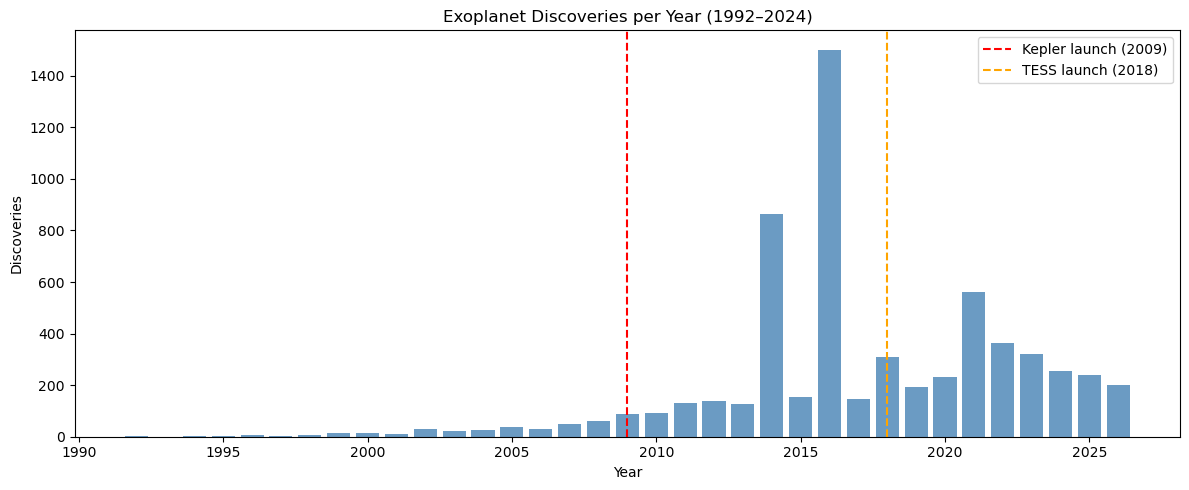

In [31]:
import matplotlib.pyplot as plt

yearly_pd = yearly.toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(yearly_pd['disc_year'], yearly_pd['discoveries'],
       color='steelblue', alpha=0.8)
ax.axvline(x=2009, color='red',    linestyle='--', linewidth=1.5,
           label='Kepler launch (2009)')
ax.axvline(x=2018, color='orange', linestyle='--', linewidth=1.5,
           label='TESS launch (2018)')
ax.set_xlabel('Year')
ax.set_ylabel('Discoveries')
ax.set_title('Exoplanet Discoveries per Year (1992–2024)')
ax.legend()
plt.tight_layout()
plt.savefig('viz1_discoveries_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

## 21. Visualization 2 — Discovery Methods

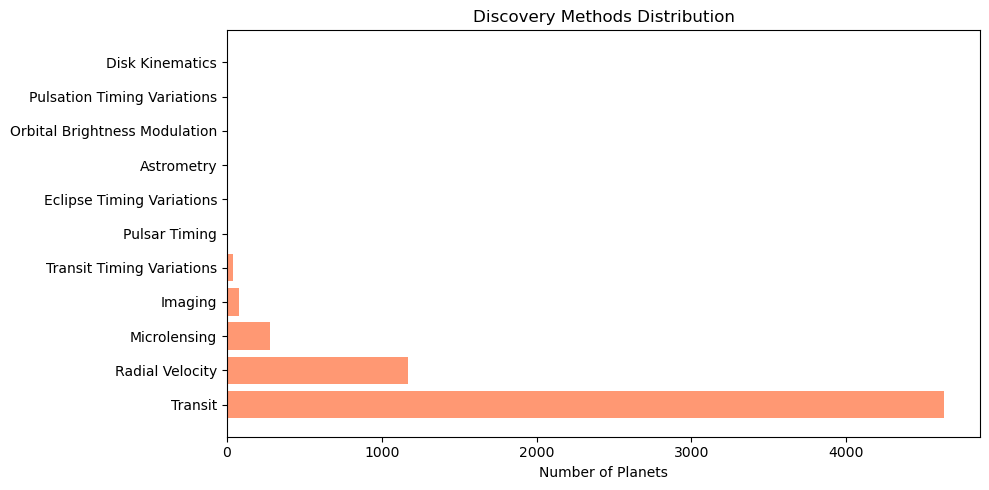

In [32]:
methods_pd = methods.toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(methods_pd['discoverymethod'], methods_pd['count'],
        color='coral', alpha=0.8)
ax.set_xlabel('Number of Planets')
ax.set_title('Discovery Methods Distribution')
plt.tight_layout()
plt.savefig('viz2_discovery_methods.png', dpi=150, bbox_inches='tight')
plt.show()

## 22. Visualization 3 — Planet Type Distribution

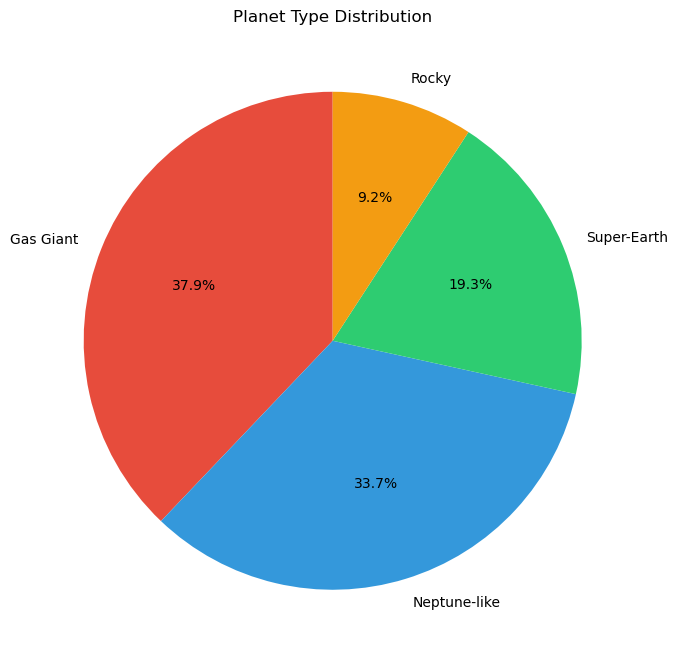

In [33]:
planet_type_pd = pscomp_c.groupBy('planet_type').count() \
                          .orderBy('count', ascending=False).toPandas()

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(planet_type_pd['count'],
       labels=planet_type_pd['planet_type'],
       colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Planet Type Distribution')
plt.tight_layout()
plt.savefig('viz3_planet_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 23. Visualization 4 — Top Discovery Facilities

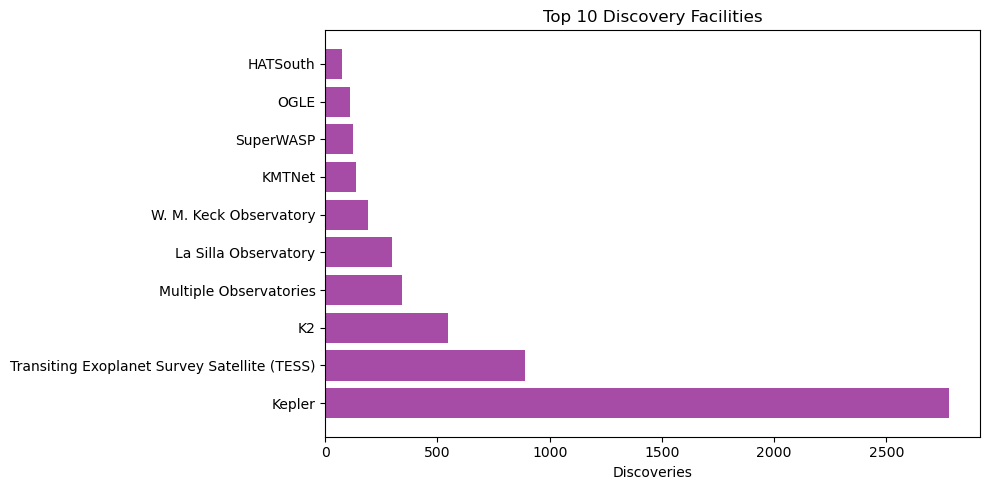

In [34]:
facility_pd = facilities.toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(facility_pd['disc_facility'], facility_pd['discoveries'],
        color='purple', alpha=0.7)
ax.set_xlabel('Discoveries')
ax.set_title('Top 10 Discovery Facilities')
plt.tight_layout()
plt.savefig('viz4_facilities.png', dpi=150, bbox_inches='tight')
plt.show()

## 24. Visualization 5 — Planet Types per Decade

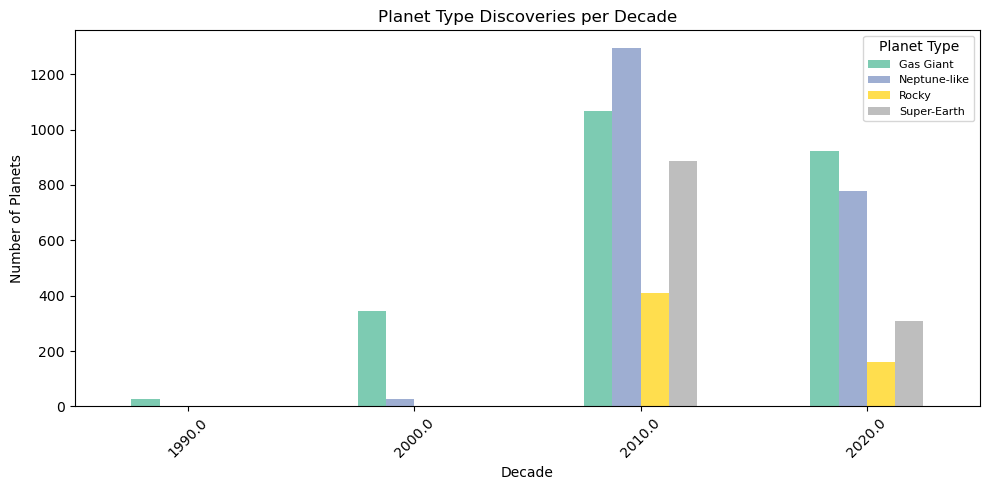

In [35]:
decade_pd = decade_types.toPandas()

pivot = decade_pd.pivot_table(
    index='disc_decade', columns='planet_type',
    values='count', fill_value=0
)
fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, colormap='Set2', alpha=0.85)
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Planets')
ax.set_title('Planet Type Discoveries per Decade')
ax.legend(title='Planet Type', fontsize=8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('viz5_decade_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 25. Visualization 6 — Habitable Zone by Stellar Class

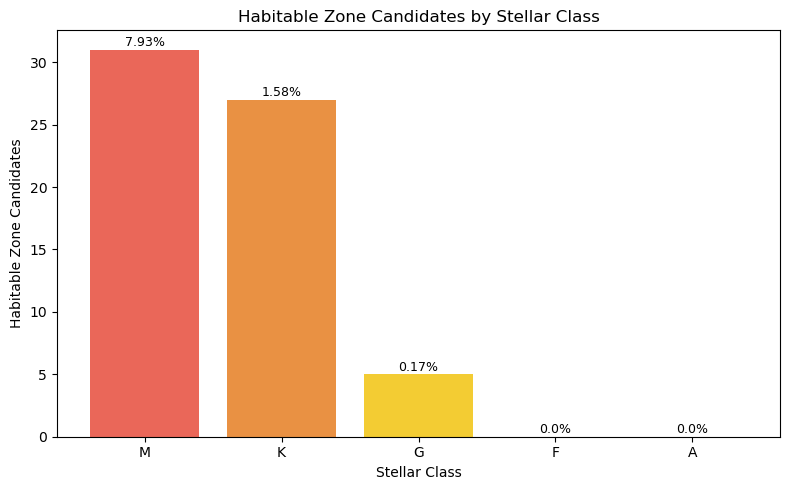

In [36]:
hab_pd = hab_stellar.toPandas()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(hab_pd['stellar_class'],
              hab_pd['habitable_candidates'],
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
              alpha=0.85)
ax.set_xlabel('Stellar Class')
ax.set_ylabel('Habitable Zone Candidates')
ax.set_title('Habitable Zone Candidates by Stellar Class')
for bar, pct in zip(bars, hab_pd['pct_habitable']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{pct}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('viz6_habitable_zone.png', dpi=150, bbox_inches='tight')
plt.show()

## 26. Visualization 7 — K-Means Clustering: Mass vs Radius

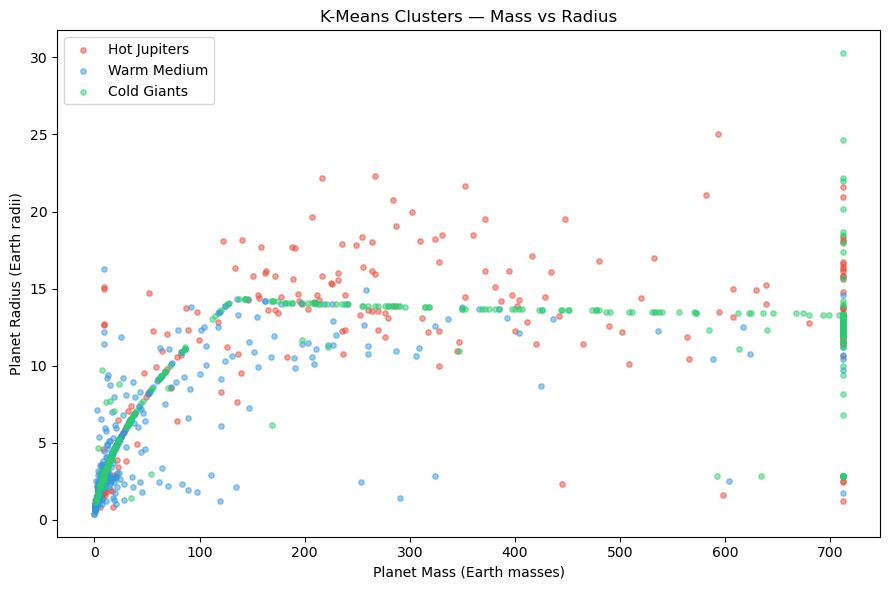

In [37]:
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71']
cluster_labels = ['Hot Jupiters', 'Warm Medium', 'Cold Giants']

clustered_sample = pscomp_clustered.select(
    'pl_bmasse', 'pl_rade', 'cluster'
).sample(0.3, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(3):
    mask = clustered_sample['cluster'] == i
    ax.scatter(clustered_sample[mask]['pl_bmasse'],
               clustered_sample[mask]['pl_rade'],
               c=cluster_colors[i], label=cluster_labels[i],
               alpha=0.5, s=15)
ax.set_xlabel('Planet Mass (Earth masses)')
ax.set_ylabel('Planet Radius (Earth radii)')
ax.set_title('K-Means Clusters — Mass vs Radius')
ax.legend()
plt.tight_layout()
plt.savefig('viz7_clusters_mass_radius.png', dpi=150, bbox_inches='tight')
plt.show()

## 27. Visualization 8 — K-Means Clustering: Orbital Period vs Temperature

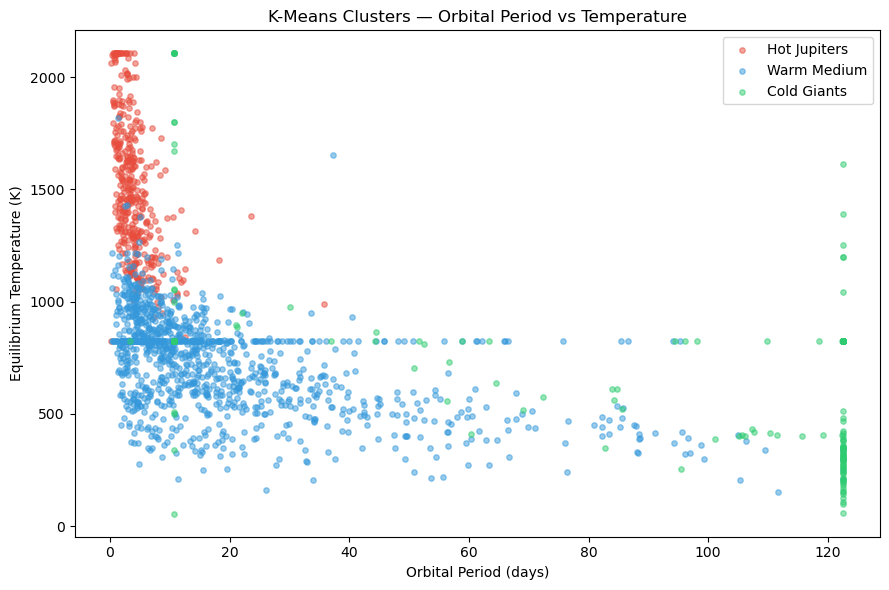

In [38]:
clustered_sample2 = pscomp_clustered.select(
    'pl_orbper', 'pl_eqt', 'cluster'
).sample(0.3, seed=42).toPandas()

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(3):
    mask = clustered_sample2['cluster'] == i
    ax.scatter(clustered_sample2[mask]['pl_orbper'],
               clustered_sample2[mask]['pl_eqt'],
               c=cluster_colors[i], label=cluster_labels[i],
               alpha=0.5, s=15)
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Equilibrium Temperature (K)')
ax.set_title('K-Means Clusters — Orbital Period vs Temperature')
ax.legend()
plt.tight_layout()
plt.savefig('viz8_clusters_period_temp.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# ══════════════════════════════════════
# Save cleaned data for Web App
# ══════════════════════════════════════

print("Saving cleaned data...")

# Save planet data
pscomp_c.select(
    'pl_name', 'hostname', 'discoverymethod', 'disc_year',
    'disc_facility', 'pl_orbper', 'pl_rade', 'pl_bmasse',
    'pl_eqt', 'pl_orbsmax', 'pl_insol', 'st_teff', 'st_rad',
    'st_mass', 'st_logg', 'st_met', 'sy_dist', 'ra', 'dec',
    'planet_type', 'habitable_zone', 'stellar_class',
    'disc_decade', 'mass_radius_ratio'
).toPandas().to_csv('/home/jovyan/planets_app.csv', index=False)
print("✅ planets_app.csv saved")

# Save KOI data
cumul_c.select(
    'kepid', 'koi_disposition', 'koi_period', 'koi_prad',
    'koi_teq', 'koi_score', 'koi_steff', 'koi_srad',
    'koi_insol', 'stellar_class', 'is_planet', 'transit_ratio'
).toPandas().to_csv('/home/jovyan/koi_app.csv', index=False)
print("✅ koi_app.csv saved")

print("\nDone! Files saved.")

Saving cleaned data...
✅ planets_app.csv saved
✅ koi_app.csv saved

Done! Files saved.
